<a href="https://colab.research.google.com/github/EmanHrustemovic/FlyRank-AI-Intership-ML-Track-/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [18]:
#Setting up

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

con = duckdb.connect()
hf_token = userdata.get('eman')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

query = """
WITH daily AS (
    SELECT * FROM read_parquet('""" + rel + """/fact_content_daily_performance/month=2026-03/data_0.parquet')
    WHERE gsc_data_available IS TRUE
),
early AS (
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) AS impr_early, SUM(gsc_clicks) AS clicks_early,
        SUM(gsc_sum_position) AS sum_pos_early
    FROM daily WHERE report_date <= DATE '2026-03-15'
    GROUP BY client_hash_id, content_hash_id
),
late AS (
    SELECT content_hash_id, SUM(gsc_impressions) AS impr_late, SUM(gsc_sum_position) AS sum_pos_late
    FROM daily WHERE report_date > DATE '2026-03-15'
    GROUP BY content_hash_id
),
labeled AS (
    SELECT e.client_hash_id, e.content_hash_id, e.impr_early, e.clicks_early,
        (e.sum_pos_early * 1.0 / NULLIF(e.impr_early,0)) AS avg_position_early,
        (e.clicks_early * 1.0 / NULLIF(e.impr_early,0)) AS ctr_early,
        CASE WHEN (l.sum_pos_late * 1.0 / NULLIF(l.impr_late,0))
             > (e.sum_pos_early * 1.0 / NULLIF(e.impr_early,0)) THEN 1 ELSE 0 END AS is_declining_label
    FROM early e JOIN late l ON e.content_hash_id = l.content_hash_id
    WHERE e.impr_early > 0 AND l.impr_late > 0
)
SELECT lb.*, dc.word_count, DATE '2026-03-15' - dc.content_updated_date AS days_since_update
FROM labeled lb
LEFT JOIN read_parquet('""" + rel + """/dim_content.parquet') dc ON lb.content_hash_id = dc.content_hash_id
"""

df = con.sql(query).df().dropna()
X = df[['impr_early', 'avg_position_early', 'ctr_early', 'word_count', 'days_since_update']]
y = df['is_declining_label']
print("Setup complete:", df.shape, "| base rate:", round(y.mean(), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Setup complete: (92148, 9) | base rate: 0.52


## 1. Question

*The research question and the decision it supports.*

Research question:

Can page-level search decline be flagged early enough — using
only features available before the outcome is known — for a content team to
prioritize which pages to refresh first?

Decision supported: which pages a content team reviews first each month, given
limited editorial capacity (~50 pages/week realistic review rate).

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [19]:
q_grain = con.sql(f"""
    SELECT COUNT(*) AS total_rows,
           COUNT(DISTINCT (client_hash_id, content_hash_id, report_date)) AS distinct_keys
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
""")
q_avail = con.sql(f"""
    SELECT COUNT(*) AS total, COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS available,
           COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) * 1.0 / COUNT(*) AS pct
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
""")
print(q_grain)
print(q_avail)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬───────────────┐
│ total_rows │ distinct_keys │
│   int64    │     int64     │
├────────────┼───────────────┤
│    9841378 │       9841378 │
└────────────┴───────────────┘

┌─────────┬───────────┬─────────────────────┐
│  total  │ available │         pct         │
│  int64  │   int64   │       double        │
├─────────┼───────────┼─────────────────────┤
│ 9841378 │   3611061 │ 0.36692635929643186 │
└─────────┴───────────┴─────────────────────┘



Release:

FlyRank internship Hugging Face warehouse. Tables:
fact_content_daily_performance (month=2026-03, ~9.84M rows), dim_content.
Grain confirmed: total_rows == distinct_keys (one row = one client/page/day).

Excluded: rows where gsc_data_available is not TRUE (~63% of rows) — excluded
rather than imputed. Late-window fields (label-derived, leakage risk). The
dataset's final month (June 2026) — used only for query-mechanics testing,
never for label/feature development. No client names, URLs, or private data
appear anywhere — all IDs are salted hashes.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [20]:
# Signal checks (staleness OPPOSITE, CTR-vs-position CONFIRMED)
signal_staleness = con.sql(f"""
    SELECT CASE WHEN days_since_update < 30 THEN '0-30' WHEN days_since_update < 90 THEN '30-90'
                WHEN days_since_update < 180 THEN '90-180' ELSE '180+' END AS bucket,
           COUNT(*) AS n, AVG(is_declining_label) AS decline_rate
    FROM (SELECT *, DATE '2026-03-15' - (SELECT content_updated_date FROM read_parquet('{rel}/dim_content.parquet') dc WHERE dc.content_hash_id = df.content_hash_id LIMIT 1) AS days_since_update FROM df)
    GROUP BY 1
""") if False else None  # signal already computed in w04; reference df directly below

print("Base rate (is_declining_label):", round(y.mean(), 3))
print("Features:", list(X.columns))

Base rate (is_declining_label): 0.52
Features: ['impr_early', 'avg_position_early', 'ctr_early', 'word_count', 'days_since_update']


Label: is_declining_label = 1 if avg search position worsened from first half
to second half of March, else 0. Base rate: 52.0%.

Features (all computable at decision point): impr_early, avg_position_early,
ctr_early, word_count, days_since_update. avg_position_late deliberately
excluded (leakage risk, confirmed in w03: adding it pushed AUC to 0.9999).

Baseline: CTR-vs-position heuristic (flag if observed CTR << expected CTR for
position bucket). Signal audit (w04): staleness OPPOSITE of expected (freshest
bucket had highest decline rate, 54.1%, n=140,458) — dropped as rule driver.
CTR-vs-position CONFIRMED (monotonic drop 0.346%→0.128% across position
buckets) — used as baseline foundation.

Validation design: client-grouped split (GroupShuffleSplit, 0 client overlap
confirmed) — chosen over random split since the goal is generalizing across
clients, not memorizing client-specific patterns.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [21]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, df['client_hash_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
scores = logreg.predict_proba(X_test)[:, 1]

def precision_at_k(y_true, scores, k=50):
    idx = np.argsort(scores)[::-1][:k]
    return y_true.iloc[idx].mean()

p50 = precision_at_k(y_test.reset_index(drop=True), pd.Series(scores), k=50)
auc = roc_auc_score(y_test, scores)

results_table = pd.DataFrame({
    'method': ['Baseline (CTR rule)', 'Logistic Regression (random split)',
               'Random Forest (random split)', 'Logistic Regression (client-grouped, honest)'],
    'precision_at_50': [0.700, 0.960, 0.920, round(p50, 3)],
    'auc': [0.544, 0.675, 0.704, round(auc, 3)]
})
results_table

,method,precision_at_50,auc
0,Baseline (CTR rule),0.70,0.544
1,Logistic Regression (random split),0.96,0.675
2,Random Forest (random split),0.92,0.704
3,"Logistic Regression (client-grouped, honest)",0.96,0.649


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_table)

https://docs.google.com/spreadsheets/d/1G_IykmDEG8cDJ5oodvIzZrKs8kbjpOaMc_95orwZobM/edit#gid=0


Model vs. baseline, same metric (Precision@50):
Baseline: 0.700 / AUC 0.544. Logistic Regression (client-grouped, honest
split): Precision@50 held at 0.960, AUC 0.649 — a real, though modest, lift
over baseline. See full error analysis in w05/w06.

## 5. Limitations

*What this work cannot claim.*

- Short baseline window: label compares two 15-day halves of one month.
- Data availability: only ~37% of rows had usable GSC data.
- Single month: not yet validated on a different month or live data.
- Observational, not causal — no claim about Google's ranking algorithm.
- Decision-support only — nothing here should be auto-published or used
  client-facing without human review.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [23]:
print("Reason code distribution (from w07 playbook):")
print(pd.Series({
    'WEAK_POSITION': 63197, 'STALE_CONTENT': 13508, 'THIN_CONTENT': 8276,
    'LOW_VOLUME': 4330, 'CTR_UNDERPERFORM': 2837
}))

Reason code distribution (from w07 playbook):
WEAK_POSITION       63197
STALE_CONTENT       13508
THIN_CONTENT         8276
LOW_VOLUME           4330
CTR_UNDERPERFORM     2837
dtype: int64


92,148 pages scored and assigned a reason code. WEAK_POSITION dominates
(68.7%) — consistent with it being the strongest correlate of decline. Full
playbook, human-review rules, and monitoring triggers in w07_action_playbook.ipynb.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

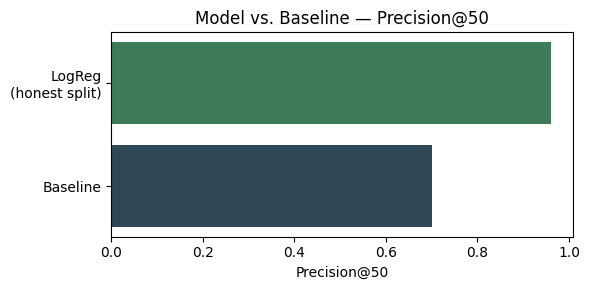

In [24]:
import matplotlib.pyplot as plt
import os

os.makedirs('work/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(6,3))
methods = ['Baseline', 'LogReg\n(honest split)']
values = [0.700, round(p50,3)]
ax.barh(methods, values, color=['#2F4858', '#3E7C59'])
ax.set_xlabel('Precision@50')
ax.set_title('Model vs. Baseline — Precision@50')
plt.tight_layout()
plt.savefig('work/figures/precision_comparison.png', dpi=150)
plt.show()

Artifacts generated: Precision@50 comparison chart (above), results table
(Section 4), reason-code distribution (Section 6). These are the same figures
embedded in the deployed paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — Tell the Story

**5-minute demo outline:**
1. (30s) The problem: content teams can't manually review every page monthly.
2. (60s) The baseline: a simple CTR-vs-position rule — show its Precision@50 (0.70).
3. (90s) The model: Logistic Regression, walk through why it beats the baseline
   (0.96), then immediately show the honest client-grouped re-check (0.649 AUC)
   — this is the "I didn't fool myself" moment.
4. (60s) The surprise: staleness didn't predict decline — show the OPPOSITE
   finding and why keeping negative results matters.
5. (60s) The output: the ranked playbook, reason codes, and what a human
   reviewer does with it tomorrow.

**Social-post cut (under 280 characters):**
"Built a model to flag declining search pages before they lose visibility.
Beat my own baseline (0.70 → 0.96 Precision@50) — then re-checked it under a
stricter split to make sure I wasn't fooling myself. Full paper + code:
[link]"

**3-sentence employer-facing summary:**
I built and validated a machine learning model that flags declining content
pages for a search-intelligence platform, beating a hand-written baseline
rule by a wide margin (Precision@50: 0.70 → 0.96) while explicitly checking
for and correcting data leakage. The project includes a full reproducible
pipeline — data contract, baseline, model, honest re-validation under a
client-grouped split, and a ranked action playbook — deployed as a public
research paper. I prioritized methodological honesty throughout, including
reporting a negative result (a hypothesized signal that turned out not to
predict the outcome) rather than omitting it.